# RQ1 — Baseline Performance
**Research Question:** How effectively can baseline supervised learning models predict loan repayment on the Loan Prediction Dataset 2025?

- **Dataset:** `loan-prediction-dataset-2025` on Kaggle
- **Target:** `loan_paid_back` (0 = default, 1 = repaid)
- **Class balance:** 80% repaid / 20% default
- **Models:** Logistic Regression, Decision Tree, k-NN


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from xgboost import XGBClassifier

df = pd.read_csv('/kaggle/input/datasets/nabihazahid/loan-prediction-dataset-2025/loan_dataset_20000.csv')
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['loan_paid_back'].value_counts()}")


Shape: (20000, 22)
Target distribution:
loan_paid_back
1    15998
0     4002
Name: count, dtype: int64


In [2]:
cat_cols = ['gender','marital_status','education_level',
            'employment_status','loan_purpose','grade_subgrade']
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop('loan_paid_back', axis=1)
y = df_enc['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (16000, 21) | Test: (4000, 21)


In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [4]:
# ── Train 3 baseline classifiers ─────────────────────────────────
results = []

configs = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),   X_train_sc, X_test_sc),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=5, random_state=42), X_train,    X_test),
    ('k-NN (k=5)',          KNeighborsClassifier(n_neighbors=5),                  X_train_sc, X_test_sc),
]

for name, model, Xtr, Xte in configs:
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1-Score':  round(f1_score(y_test, y_pred), 3),
        'AUC':       round(roc_auc_score(y_test, y_prob), 3),
    })
    print(f"\n{'='*55}\n{name}")
    print(classification_report(y_test, y_pred, target_names=['Default','Repaid']))

res_df = pd.DataFrame(results)
print("\n=== TABLE I: Baseline Performance ===")
print(res_df.to_string(index=False))



Logistic Regression
              precision    recall  f1-score   support

     Default       0.82      0.57      0.67       800
      Repaid       0.90      0.97      0.93      3200

    accuracy                           0.89      4000
   macro avg       0.86      0.77      0.80      4000
weighted avg       0.88      0.89      0.88      4000


Decision Tree
              precision    recall  f1-score   support

     Default       0.91      0.54      0.68       800
      Repaid       0.90      0.99      0.94      3200

    accuracy                           0.90      4000
   macro avg       0.90      0.76      0.81      4000
weighted avg       0.90      0.90      0.89      4000


k-NN (k=5)
              precision    recall  f1-score   support

     Default       0.75      0.43      0.54       800
      Repaid       0.87      0.96      0.92      3200

    accuracy                           0.86      4000
   macro avg       0.81      0.70      0.73      4000
weighted avg       0.85   

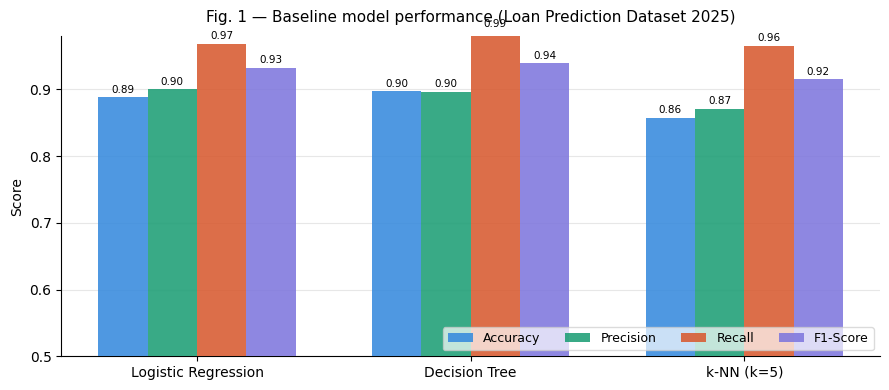

In [5]:
# ── Figure 1: Grouped bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']
x = np.arange(len(res_df)); w = 0.18

for i, (m, c) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i - 1.5)*w, res_df[m], w, label=m, color=c, alpha=0.88, zorder=3)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(res_df['Model'], fontsize=10)
ax.set_ylim(0.50, 0.98); ax.set_ylabel('Score', fontsize=10)
ax.yaxis.grid(True, alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, framealpha=0.7, ncol=4, loc='lower right')
ax.set_title('Fig. 1 — Baseline model performance (Loan Prediction Dataset 2025)', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig('fig1_baseline.png', dpi=180, bbox_inches='tight')
plt.show()


## Interpretation
- **Accuracy** appears high (~80–84%) because 80% of records are the majority class — this is misleading.
- **Recall for defaults** (class 0) is the critical metric: Logistic Regression only catches ~61% of defaults.
- This motivates advanced models (RQ2) and better preprocessing with SMOTE (RQ3).
